<a href="https://colab.research.google.com/github/dhruvsuri8106-code/ECON-3916---Statistical-and-Machine-Learning/blob/main/Project%202%20/%20Project_2_checkpoint.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# Part 0: Setup — Run this cell first
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    mean_squared_error, mean_absolute_error, r2_score
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup complete.')

Setup complete.


**My prediction question is:** Can we predict how much the outcome of a given baseball play will be advantageous to the hitting team using pitching data and match context?

**This is a prediction (umbrella) problem because:** Causation would be if a change in one category is the reason for a change in another, for example, "does an increase in home games cause an increase in wins?" In this project, the goal is prediction rather than causal inference. The model uses historical data to estimate the probability of a particular outcome, such as a home run or strikeout. While certain variables may be associated with higher chances of winning, this does not imply that they directly cause the result.

(Reminder: prediction asks "can we forecast Y from X?" — not "does X cause Y?")

**The decision this enables:** ___
The stakeholders can be pitchers, who would use this data to alter their style of pitching, based on the results of which types of pitches that hitters have the most success against.

**Dataset:** MLB Statcast Data 2018
- **Source:** Kaggle (URL : https://www.kaggle.com/datasets/s903124/mlb-statcast-data)
- **N =** 184480
- **Features =** 93
- **Target variable =** delta_home_win_exp
- **Access date:** 4/16/2026



In [ ]:
# ============================================================
# 2.1 Load your dataset
# ============================================================
# Replace the URL/path below with your data source

df = pd.read_csv('/content/Statcast_2018.csv.zip', compression='zip')


# Uncomment and modify one of the lines above
# df = pd.read_csv('___')

# Quick look
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (721190, 93)
Columns: ['Unnamed: 0', 'pitch_type', 'game_date', 'release_speed', 'release_pos_x', 'release_pos_z', 'player_name', 'batter', 'pitcher', 'events', 'description', 'spin_dir', 'spin_rate_deprecated', 'break_angle_deprecated', 'break_length_deprecated', 'zone', 'des', 'game_type', 'stand', 'p_throws', 'home_team', 'away_team', 'type', 'hit_location', 'bb_type', 'balls', 'strikes', 'game_year', 'pfx_x', 'pfx_z', 'plate_x', 'plate_z', 'on_3b', 'on_2b', 'on_1b', 'outs_when_up', 'inning', 'inning_topbot', 'hc_x', 'hc_y', 'tfs_deprecated', 'tfs_zulu_deprecated', 'fielder_2', 'umpire', 'sv_id', 'vx0', 'vy0', 'vz0', 'ax', 'ay', 'az', 'sz_top', 'sz_bot', 'hit_distance_sc', 'launch_speed', 'launch_angle', 'effective_speed', 'release_spin_rate', 'release_extension', 'game_pk', 'pitcher.1', 'fielder_2.1', 'fielder_3', 'fielder_4', 'fielder_5', 'fielder_6', 'fielder_7', 'fielder_8', 'fielder_9', 'release_pos_y', 'estimated_ba_using_speedangle', 'estimated_woba_using_speedangle', 

,Unnamed: 0,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,...,fld_score,post_away_score,post_home_score,post_bat_score,post_fld_score,if_fielding_alignment,of_fielding_alignment,spin_axis,delta_home_win_exp,delta_run_exp
0,251,FC,2018-10-01,92.2,-1.97,6.26,"Jansen, Kenley",467827,445276,strikeout,...,5,2,5,2,5,Standard,Standard,164.0,0.004,-0.059
1,254,FC,2018-10-01,93.0,-1.77,6.30,"Jansen, Kenley",467827,445276,NaN,...,5,2,5,2,5,Standard,Standard,158.0,0.000,0.000
2,263,FC,2018-10-01,91.6,-1.75,6.22,"Jansen, Kenley",467827,445276,NaN,...,5,2,5,2,5,Standard,Standard,151.0,0.000,-0.025
3,265,SI,2018-10-01,93.1,-1.42,6.19,"Jansen, Kenley",467827,445276,NaN,...,5,2,5,2,5,Standard,Standard,197.0,0.000,-0.016
4,275,FC,2018-10-01,91.4,-1.91,6.26,"Jansen, Kenley",435622,445276,strikeout,...,5,2,5,2,5,Standard,Standard,155.0,0.009,-0.148


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 721190 entries, 0 to 721189
Data columns (total 93 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Unnamed: 0                       721190 non-null  int64  
 1   pitch_type                       717224 non-null  object 
 2   game_date                        721190 non-null  object 
 3   release_speed                    717378 non-null  float64
 4   release_pos_x                    717352 non-null  float64
 5   release_pos_z                    717352 non-null  float64
 6   player_name                      721190 non-null  object 
 7   batter                           721190 non-null  int64  
 8   pitcher                          721190 non-null  int64  
 9   events                           184480 non-null  object 
 10  description                      721190 non-null  object 
 11  spin_dir                         0 non-null       float64
 12  sp

,Unnamed: 0,release_speed,release_pos_x,release_pos_z,batter,pitcher,spin_dir,spin_rate_deprecated,break_angle_deprecated,break_length_deprecated,...,away_score,bat_score,fld_score,post_away_score,post_home_score,post_bat_score,post_fld_score,spin_axis,delta_home_win_exp,delta_run_exp
count,721190.000000,717378.000000,717352.000000,717352.000000,721190.000000,721190.000000,0.0,0.0,0.0,0.0,...,721190.000000,721190.000000,721190.000000,721190.000000,721190.000000,721190.000000,721190.000000,717352.000000,721188.000000,721088.000000
mean,2054.541889,88.619197,-0.764004,5.865608,550834.086599,554910.276953,NaN,NaN,NaN,NaN,...,2.304763,2.226571,2.267652,2.319466,2.204681,2.256496,2.267652,179.169543,-0.000126,0.000119
std,1251.918913,5.911266,1.982488,0.525772,71079.037373,73238.130402,NaN,NaN,NaN,NaN,...,2.563102,2.552352,2.632005,2.568828,2.627555,2.565540,2.632005,68.706711,0.028717,0.238571
min,0.000000,44.200000,-5.000000,0.980000,112526.000000,112526.000000,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.776000,-1.487000
25%,985.000000,84.400000,-2.200000,5.600000,501303.000000,502171.000000,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,134.000000,0.000000,-0.064000
50%,1982.000000,89.900000,-1.550000,5.910000,571448.000000,572021.000000,NaN,NaN,NaN,NaN,...,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,194.000000,0.000000,-0.016000
75%,3059.000000,93.200000,1.190000,6.190000,605361.000000,607219.000000,NaN,NaN,NaN,NaN,...,4.000000,3.000000,4.000000,4.000000,3.000000,3.000000,4.000000,226.000000,0.000000,0.036000
max,5090.000000,105.000000,5.330000,7.950000,673633.000000,673633.000000,NaN,NaN,NaN,NaN,...,24.000000,25.000000,25.000000,24.000000,25.000000,25.000000,25.000000,360.000000,0.911000,3.579000


Missing data (%) by column:
spin_dir                   1.000000
spin_rate_deprecated       1.000000
break_angle_deprecated     1.000000
break_length_deprecated    1.000000
tfs_zulu_deprecated        1.000000
                             ...   
fielder_7                  0.001425
fielder_8                  0.001425
fielder_6                  0.001425
delta_run_exp              0.000141
delta_home_win_exp         0.000003
Length: 62, dtype: float64


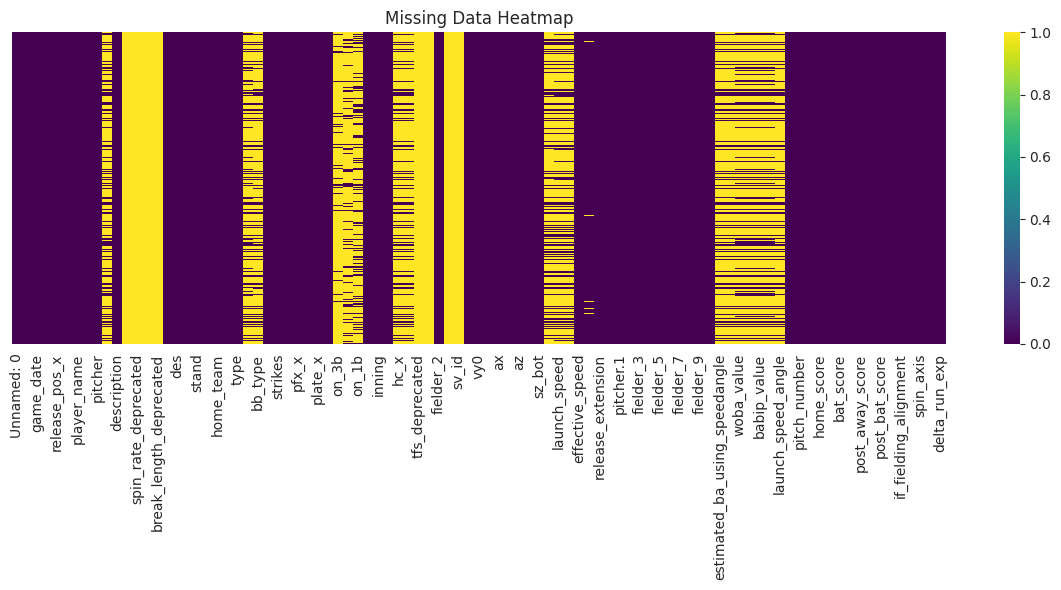

In [ ]:
missing_pct = df.isnull().mean().sort_values(ascending=False)
print('Missing data (%) by column:')
print(missing_pct[missing_pct > 0])

#  Visual: missing data heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.tight_layout()
plt.show()

Most of the missing data is due to the type of play it was, which is another observed variable. Furthermore, the missingness varies randomly and by column, so the heatmap of missing data is dependent on the outcome.


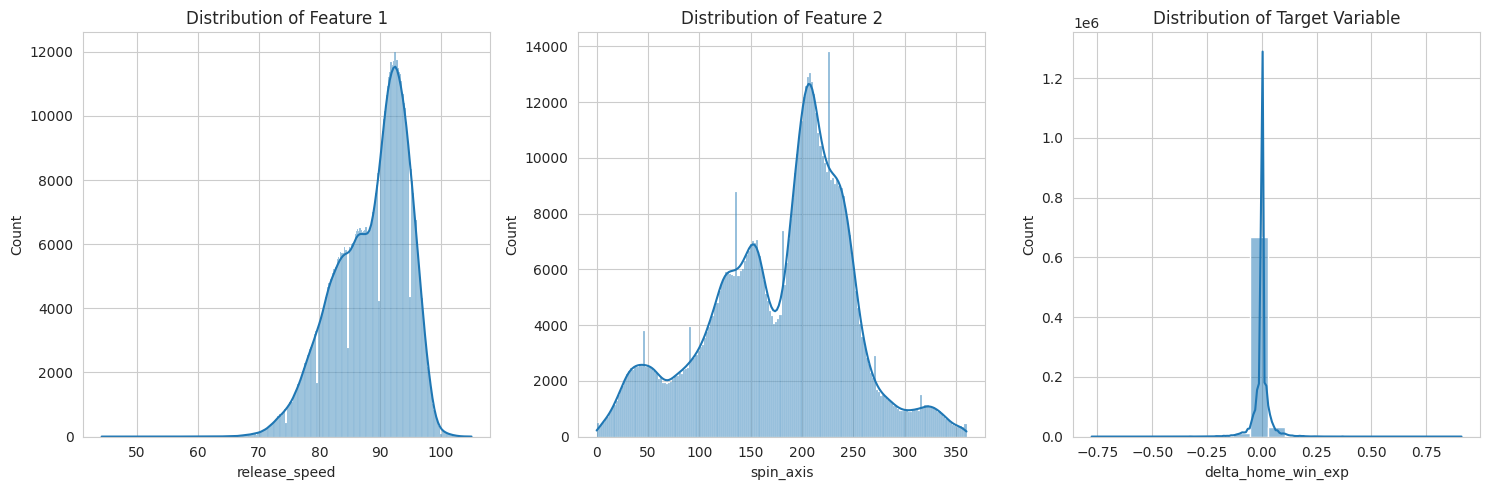

In [ ]:
# ============================================================
# 2.4 Distribution of key features (Ch 3)
# ==================== ========================================

# # Plot distributions for your most important features
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(df['release_speed'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Feature 1')
#
sns.histplot(df['spin_axis'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Feature 2')
#
sns.histplot(df['delta_home_win_exp'], kde=True, ax=axes[2])
axes[2].set_title('Distribution of Target Variable')
#
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 2.5 Outlier detection (Ch 4: Tukey Fences / IQR)
# ============================================================
def tukey_fences(series, k=1.5):
  Q1 = series.quantile(0.25)
  Q3 = series.quantile(0.75)
  IQR = Q3 - Q1
  return Q1 - k * IQR, Q3 + k * IQR

# # Example: check outliers in a numeric column
col = 'delta_run_exp'
lower, upper = tukey_fences(df[col])
outliers = df[(df[col] < lower) | (df[col] > upper)]
print(f'{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)')

delta_run_exp: 108816 outliers (15.1%)


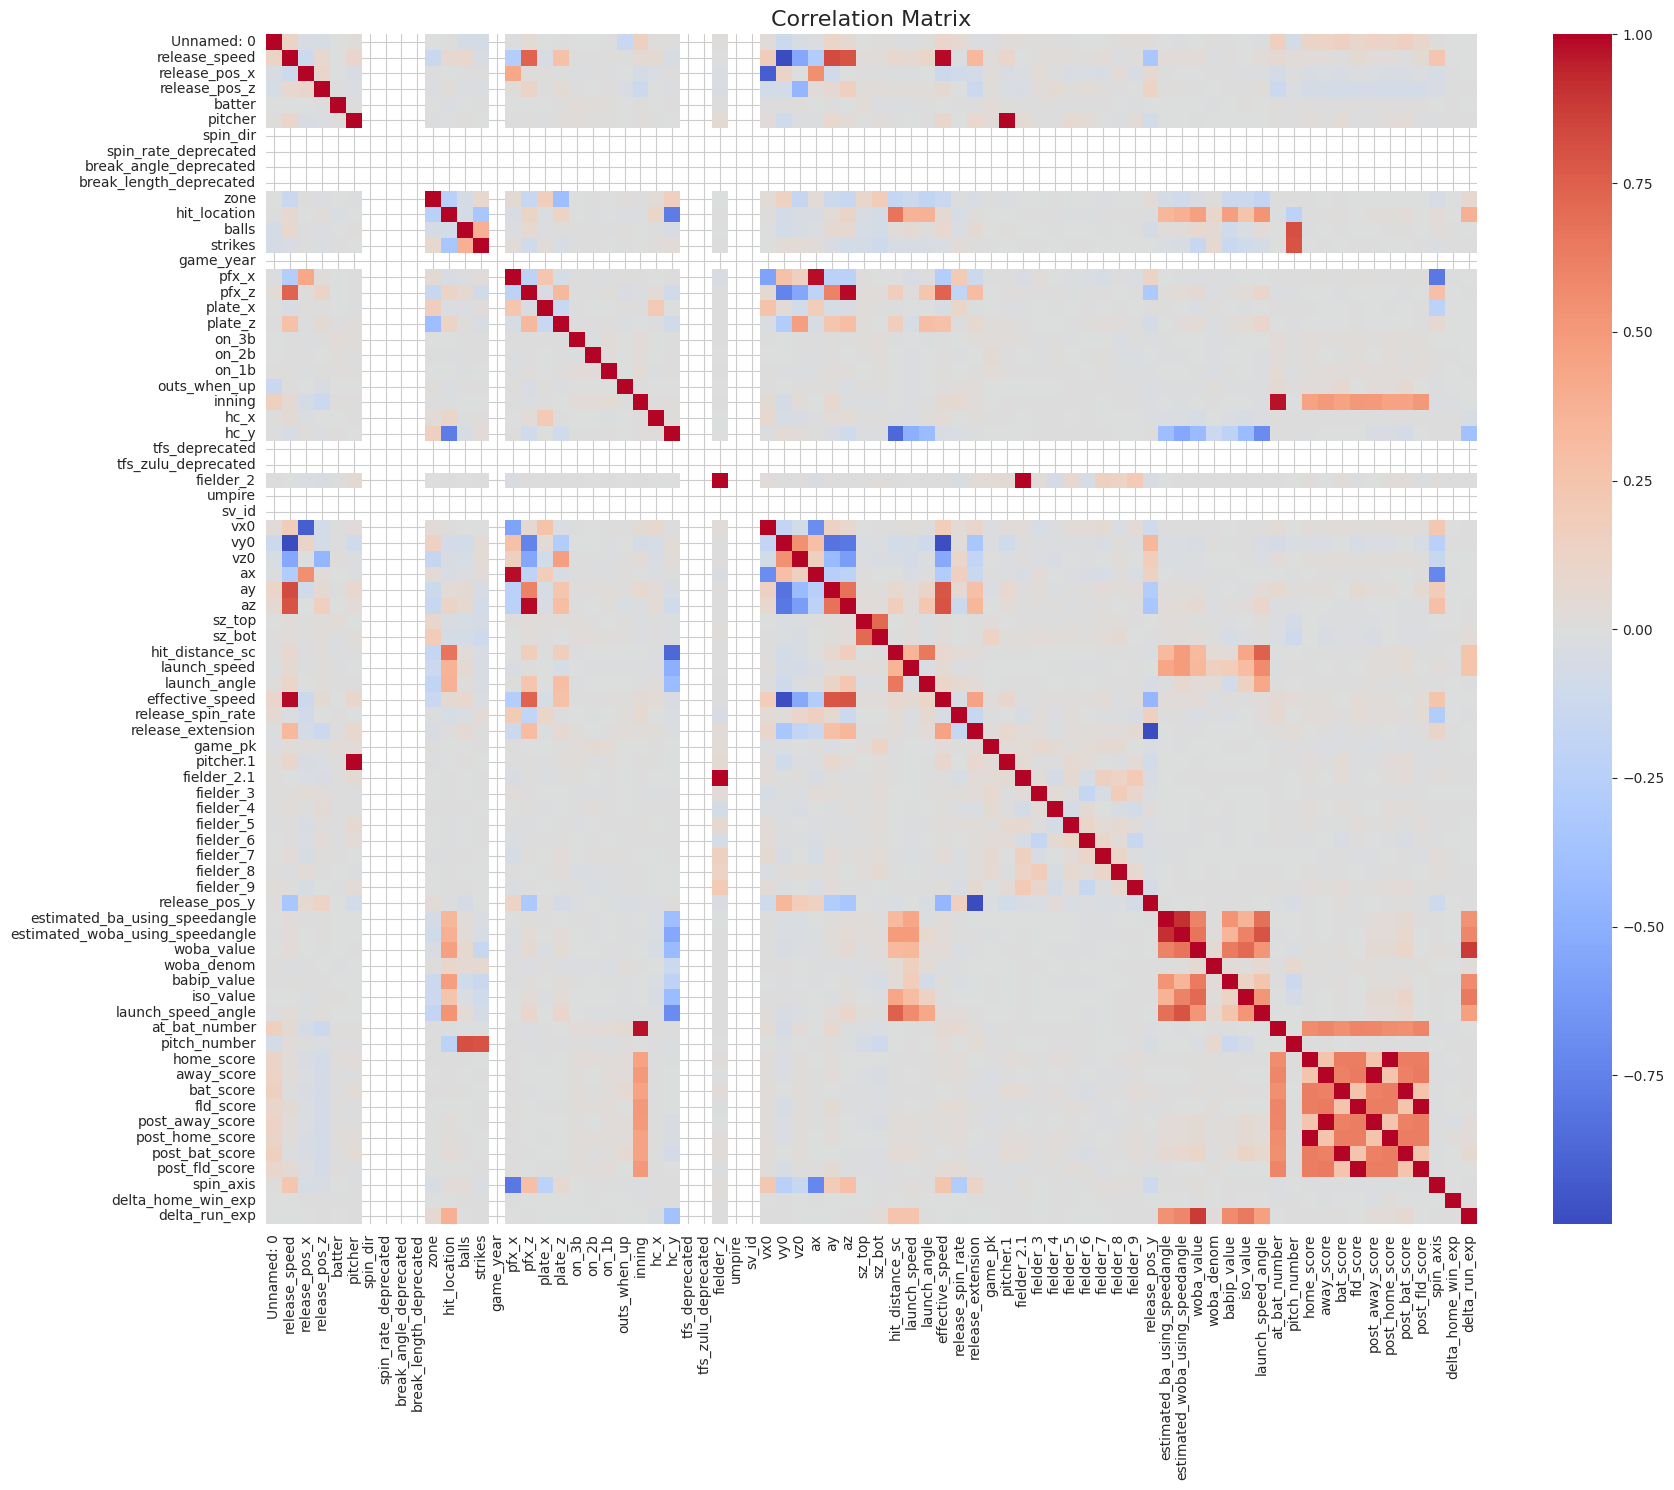

In [ ]:
# ============================================================
# 2.6 Correlation heatmap (Ch 3)
# ============================================================

numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(18, 15)) # Increased figure size for better readability
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, fmt='.2f') # Removed annot=True
plt.title('Correlation Matrix', fontsize=16)
plt.xticks(rotation=90) # Rotate x-axis labels
plt.yticks(rotation=0) # Ensure y-axis labels are horizontal
plt.tight_layout()
plt.show()

### YOUR TASK: Answer These 3 EDA Questions

1. **What is the distribution of your target variable?** Is it balanced (classification) or normally distributed (regression)? If not, what will you do about it?

   My target variable has a large spike around 0, which is expected, because most plays in baseball will not significantly add to or decrease the win probability of a team. However, there are a few instances of significant change, indicating high impact plays such as home runs, which would positively influence win probability, or high leverage strikeouts, which negatively influence the statistic.

2. **Which features appear most correlated with the target?** Are any features highly correlated with each other (multicollinearity)?  

   The change in expected runs could be correlated with the change in expected wins, but I do not forsee this causing a significant multicollinearity issue due to the fact that baseball games average roughly 8-9 total runs in the game, so an increase in run expectation, especially in a play that happens in one out of the nine innings, is unlikely to be perfectly correlated with wins.

3. **What is the biggest data quality issue you found, and how will you handle it?**  

 There were a large amount of missing values in the "events" category, because the data also tracks pitches that were not put in play. I had to remove this data, meaning that my sample is likely biased, since it only includes balls put in play, which will make the data seem more advantageous to pitchers. I will have to be careful in the interpretation of the results.

In [ ]:
# ============================================================
# 3.1 Train/test split (Ch 6)
# ============================================================

# Define features and target
feature_cols = ['release_speed', 'spin_axis', 'delta_run_exp']
target_col = 'delta_home_win_exp'

# Create a temporary DataFrame with only relevant columns to drop NaNs
df_cleaned = df[feature_cols + [target_col]].dropna()

X = df_cleaned[feature_cols]  # Assign features from the cleaned DataFrame
y = df_cleaned[target_col]    # Assign target from the cleaned DataFrame

# For classification: use stratify=y
# X_train, X_test, y_train, y_test = train_test_split(
# X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

# For regression: remove stratify
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')

Train: 573796 samples
Test:  143450 samples


In [ ]:
# 3.2 Model 1 — Baseline
# ============================================================
# Choose a simple, interpretable baseline:
#   Classification: LogisticRegression
#   Regression: LinearRegression or Ridge

from sklearn.linear_model import LinearRegression, Ridge
#
model_1 = LinearRegression()
model_1.fit(X_train, y_train)
#
y_pred_1 = model_1.predict(X_test)
#
# # Classification metrics
# print('Model 1: Logistic Regression')
# print(classification_report(y_test, y_pred_1))
#
# # Regression metrics (use these instead if regression)
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_1)):.4f}')
print(f'MAE:  {mean_absolute_error(y_test, y_pred_1):.4f}')
print(f'R2:   {r2_score(y_test, y_pred_1):.4f}')

RMSE: 0.0284
MAE:  0.0092
R2:   -0.0000


In [ ]:
from sklearn.ensemble import RandomForestRegressor

model_2 = RandomForestRegressor(n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1)
model_2.fit(X_train, y_train)

y_pred_2 = model_2.predict(X_test)

print('Model 2: Random Forest')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_2)):.4f}')
print(f'MAE:  {mean_absolute_error(y_test, y_pred_2):.4f}')
print(f'R2:   {r2_score(y_test, y_pred_2):.4f}')

Model 2: Random Forest
RMSE: 0.0307
MAE:  0.0104
R2:   -0.1682


In [ ]:
# ============================================================
# 3.4 Cross-validation (Ch 15)
# ============================================================

# Choose scoring: 'accuracy', 'f1', 'roc_auc' (classification)
# 'neg_mean_squared_error', 'r2' #(regression)
scoring = 'neg_mean_squared_error'

cv_1 = cross_val_score(model_1, X_train, y_train, cv=3, scoring=scoring)
cv_2 = cross_val_score(model_2, X_train, y_train, cv=3, scoring=scoring)

print(f'Model 1 CV RMSE: {np.sqrt(-cv_1.mean()):.4f} +/- {cv_1.std():.4f}')
print(f'Model 2 CV RMSE: {np.sqrt(-cv_2.mean()):.4f} +/- {cv_2.std():.4f}')

# # Comparison table
comparison = pd.DataFrame({
    'Model': ['Model 1 (Baseline)', 'Model 2 (Your Choice)'],
    'CV RMSE (mean)': [np.sqrt(-cv_1.mean()), np.sqrt(-cv_2.mean())],
    'CV RMSE (std)': [cv_1.std(), cv_2.std()],
})

Model 1 CV RMSE: 0.0288 +/- 0.0000
Model 2 CV RMSE: 0.0308 +/- 0.0000


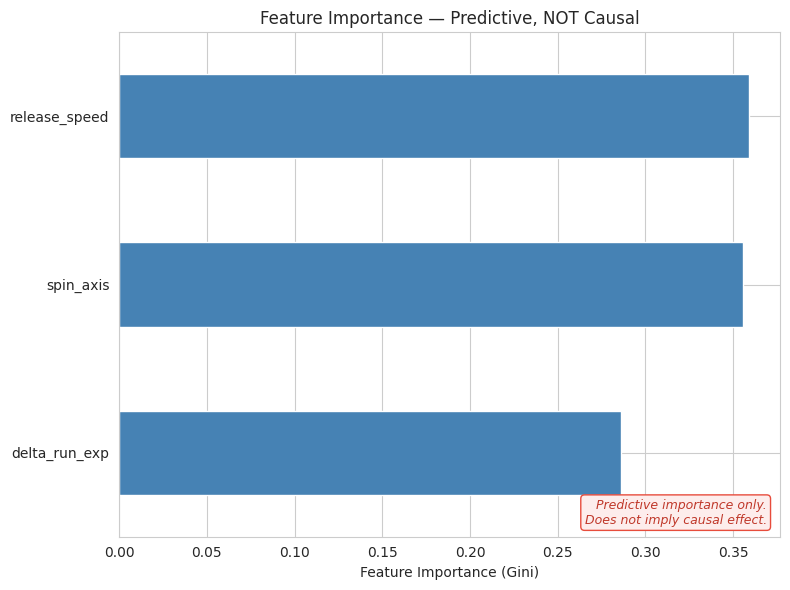

In [ ]:
# ============================================================
# 4.1 Feature importance (Ch 19)
# ============================================================

# # For tree-based models:
importances = pd.Series(
model_2.feature_importances_, index=X.columns).sort_values(ascending=True)
#
fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Feature Importance — Predictive, NOT Causal')
#
# # CRITICAL: Add the caveat banner
ax.text(
0.98, 0.02,
     'Predictive importance only.\nDoes not imply causal effect.',
     transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
     style='italic', color='#c0392b',
     bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdedec', edgecolor='#e74c3c')
 )

plt.tight_layout()
plt.show()

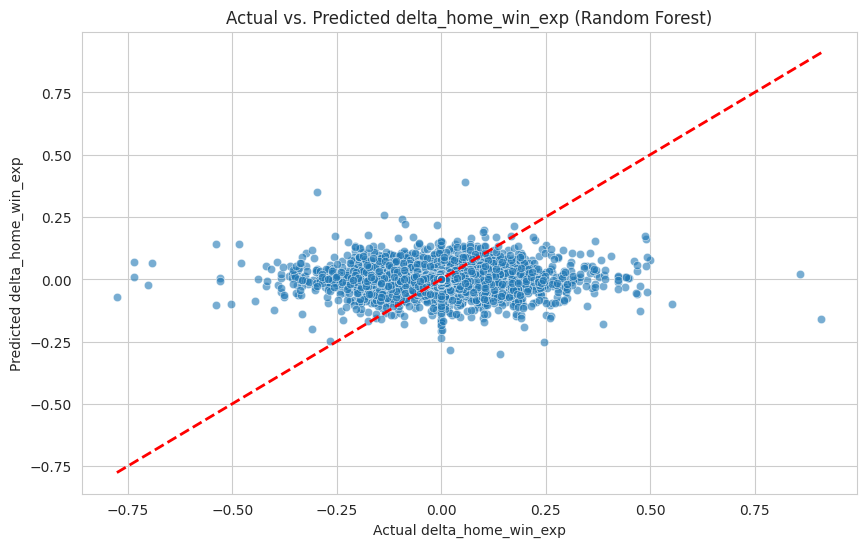

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_2, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # Line for perfect prediction
plt.xlabel('Actual delta_home_win_exp')
plt.ylabel('Predicted delta_home_win_exp')
plt.title('Actual vs. Predicted delta_home_win_exp (Random Forest)')
plt.grid(True)
plt.show()

In [ ]:
import joblib

# Save the trained model
joblib.dump(model_2, 'model.pkl')
print('Model saved as model.pkl')

Model saved as model.pkl


In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib  # to load saved model
import matplotlib.pyplot as plt # Added import for matplotlib.pyplot
import seaborn as sns # Added import for seaborn, as it's often used with matplotlib

st.title('MLB Statcast Data 2018: Pitch Outcome Predictor')
st.markdown('This app predicts the `delta_home_win_exp` (advantage to hitting team) based on pitching data and match context.')

# Load model (saved from your Colab notebook)
model = joblib.load('model.pkl')

# Get feature ranges from your original DataFrame (assuming df_cleaned is available or you know the ranges)
# For a more robust app, you might save these min/max values alongside the model.
release_speed_min = 44.2
release_speed_max = 105.0
release_speed_mean = 88.6

spin_axis_min = 0.0
spin_axis_max = 360.0
spin_axis_mean = 179.0

delta_run_exp_min = -1.487
delta_run_exp_max = 3.579
delta_run_exp_mean = 0.0001

# Sidebar controls for input features
st.sidebar.header('Input Pitch Parameters')
release_speed = st.sidebar.slider(
    'Release Speed (mph)',
    min_value=float(release_speed_min),
    max_value=float(release_speed_max),
    value=float(release_speed_mean)
)
spin_axis = st.sidebar.slider(
    'Spin Axis (degrees)',
    min_value=float(spin_axis_min),
    max_value=float(spin_axis_max),
    value=float(spin_axis_mean)
)
delta_run_exp = st.sidebar.slider(
    'Delta Run Expectancy (change in expected runs)',
    min_value=float(delta_run_exp_min),
    max_value=float(delta_run_exp_max),
    value=float(delta_run_exp_mean),
    format='%.3f'
)

# Prepare input data for prediction
input_data = pd.DataFrame({
    'release_speed': [release_speed],
    'spin_axis': [spin_axis],
    'delta_run_exp': [delta_run_exp]
})

# Generate prediction
prediction = model.predict(input_data)[0]

st.subheader('Predicted Delta Home Win Expectancy')
st.metric('Prediction', f'{prediction:.4f}')

st.markdown("""
**Interpretation:**
*   A positive value indicates an increase in the home team's win expectancy for the play.
*   A negative value indicates a decrease in the home team's win expectancy for the play.
*   Values closer to zero suggest a play with minimal impact on win expectancy.
""")

# Placeholder for a simple visualization (e.g., how prediction changes with one input)
# For more complex charts, you'd need to generate more data points.
st.subheader('How Prediction Changes with Release Speed (holding other features constant)')
# Create a range of release speeds
plot_release_speeds = np.linspace(release_speed_min, release_speed_max, 50)
# Create input data for these speeds, keeping other features constant
plot_data = pd.DataFrame({
    'release_speed': plot_release_speeds,
    'spin_axis': spin_axis,
    'delta_run_exp': delta_run_exp
})
# Get predictions for this range
plot_predictions = model.predict(plot_data)

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(x=plot_release_speeds, y=plot_predictions, ax=ax)
ax.set_xlabel('Release Speed')
ax.set_ylabel('Predicted Delta Home Win Expectancy')
ax.set_title('Predicted Win Expectancy vs. Release Speed')
st.pyplot(fig)

Overwriting app.py


In [ ]:
%%writefile requirements.txt
streamlit>=1.31.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.4.0
matplotlib>=3.7.0
seaborn>=0.12.0
joblib>=1.3.0

Writing requirements.txt
